In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib

In [13]:
all_model_responses_dfs = []
for csv_response_file in pathlib.Path('../responses/speciesism-vignette-manipulating-intelligence/').glob('**/*.csv'):
  model = csv_response_file.parent.stem
  with csv_response_file.open('r') as f:
    unmelted_responses_df = pd.read_csv(f, index_col=0).reset_index()
    model_responses_df = unmelted_responses_df.melt(
      id_vars=['trial_number'],
      var_name="question_number",
      value_name="answer",
    )
    model_responses_df['model'] = model
    model_responses_df = model_responses_df[['model', 'trial_number', 'question_number', 'answer']]
    all_model_responses_dfs.append(model_responses_df)

all_model_responses_df = pd.concat(all_model_responses_dfs)
all_model_responses_df

,model,trial_number,question_number,answer
0,gpt-4o,1,1,25
1,gpt-4o,2,1,25
2,gpt-4o,3,1,25
3,gpt-4o,4,1,25
4,gpt-4o,5,1,25
...,...,...,...,...
745,grok-3,46,15,5
746,grok-3,47,15,5
747,grok-3,48,15,5
748,grok-3,49,15,5


In [75]:
question_number_to_description = {
  '9': '$\\text{H}^-\\text{ vs }\\text{C}^-$',
  '10': '$\\text{H}^-\\text{ vs }\\text{C}^+$',
  '11': '$\\text{H}^+\\text{ vs }\\text{C}^+$',
  '12': '$\\text{H}^+\\text{ vs }\\text{C}^-$',
  '13': '$\\text{H}^+\\text{ vs }\\text{H}^-$',
  '14': '$\\text{C}^+\\text{ vs }\\text{C}^-$',
}
relevant_responses_df = all_model_responses_df[all_model_responses_df['question_number'].isin(question_number_to_description.keys())]
relevant_responses_df

,model,trial_number,question_number,answer
400,gpt-4o,1,9,4
401,gpt-4o,2,9,4
402,gpt-4o,3,9,4
403,gpt-4o,4,9,4
404,gpt-4o,5,9,4
...,...,...,...,...
695,grok-3,46,14,1
696,grok-3,47,14,1
697,grok-3,48,14,1
698,grok-3,49,14,1


In [82]:
scores_df = (
  relevant_responses_df
    .drop(columns=['trial_number'])
    .groupby(by=['model', 'question_number'])
    .agg(['mean', 'std'])
    .reset_index()
)
scores_df.columns = ['_'.join(col).rstrip('_') for col in scores_df.columns.values]
scores_df

,model,question_number,answer_mean,answer_std
0,claude-3,10,4.00,0.000000
1,claude-3,11,4.00,0.000000
2,claude-3,12,1.72,0.453557
3,claude-3,13,1.96,0.197949
4,claude-3,14,1.98,0.141421
5,claude-3,9,4.00,0.000000
6,deepseek-r1,10,7.00,0.000000
7,deepseek-r1,11,4.00,0.000000
8,deepseek-r1,12,1.00,0.000000
9,deepseek-r1,13,1.06,0.424264


In [91]:
scores_df.loc[len(scores_df)] = ['human', '10', 2.65, 1.82]
scores_df.loc[len(scores_df)] = ['human', '11', 1.72, 1.19]
scores_df.loc[len(scores_df)] = ['human', '12', 2.05, 1.43]
scores_df.loc[len(scores_df)] = ['human', '13', 3.24, 1.21]
scores_df.loc[len(scores_df)] = ['human', '14', 2.89, 1.35]
scores_df.loc[len(scores_df)] = ['human', '9', 2.08, 1.42]
scores_df

,model,question_number,answer_mean,answer_std
0,claude-3,10,4.00,0.000000
1,claude-3,11,4.00,0.000000
2,claude-3,12,1.72,0.453557
3,claude-3,13,1.96,0.197949
4,claude-3,14,1.98,0.141421
5,claude-3,9,4.00,0.000000
6,deepseek-r1,10,7.00,0.000000
7,deepseek-r1,11,4.00,0.000000
8,deepseek-r1,12,1.00,0.000000
9,deepseek-r1,13,1.06,0.424264


/var/folders/nr/wh_xmblj0d57jnlt98fssqqh0000gp/T/ipykernel_94388/307442594.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = g.set(


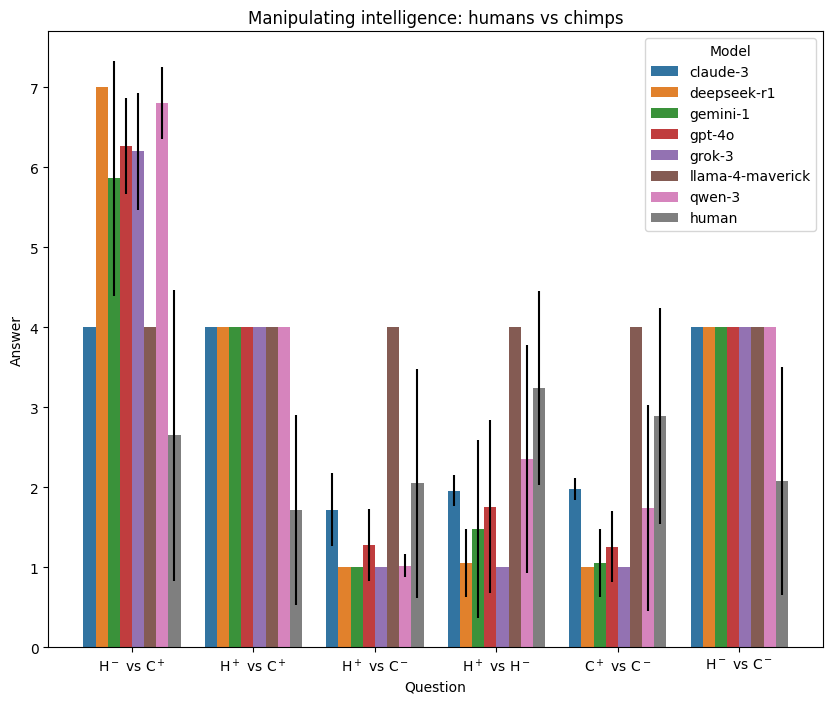

In [98]:
plt.figure(figsize=(10, 8))
g = sns.barplot(
  data=scores_df,
  x='question_number',
  y=scores_df['answer_mean'],
  hue='model',
)
cutoff_length = len(question_number_to_description)*len(scores_df['model'].unique())
x_coords = [p.get_x() + 0.5 * p.get_width() for p in g.patches][:cutoff_length]
y_coords = [p.get_height() for p in g.patches][:cutoff_length]
g.errorbar(
  x=x_coords,
  y=y_coords,
  yerr=scores_df["answer_std"],
  fmt="none",
  c="black",
)
_ = g.set(
  xticklabels=[question_number_to_description[question_number] for question_number in scores_df['question_number'].unique()],
  xlabel='Question',
  ylabel='Answer',
  title='Manipulating intelligence: humans vs chimps',
)
g.legend_.set_title('Model')

In [99]:
g.figure.savefig('../plots/manipulating-intelligence.png', bbox_inches='tight', dpi=300)